In [14]:
from transformers import GPT2LMHeadModel
import torch

In [15]:
model_hf = GPT2LMHeadModel.from_pretrained('gpt2') #124M param
sd_hf = model_hf.state_dict()

for k,v in sd_hf.items():
    print(k,v.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16406.52it/s]

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [16]:
sd_hf["transformer.wpe.weight"].view(-1)[:20]

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

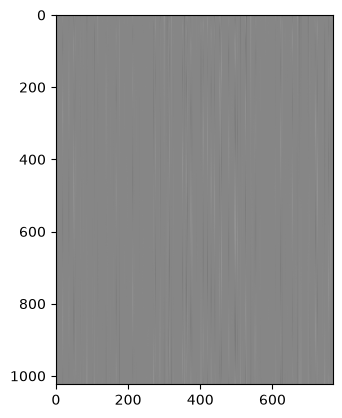

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf["transformer.wpe.weight"],cmap='grey')

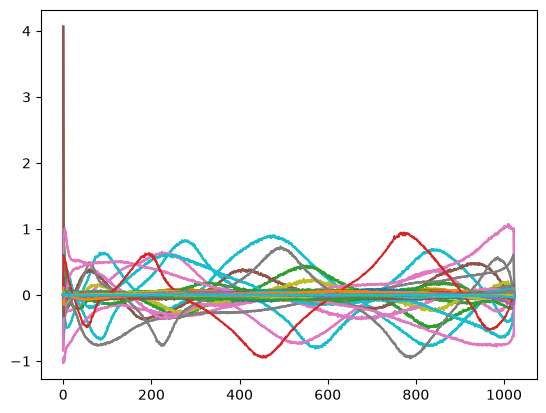

In [18]:
plt.plot(sd_hf["transformer.wpe.weight"][:,:150])
plt.plot(sd_hf["transformer.wpe.weight"][:,:200])
plt.plot(sd_hf["transformer.wpe.weight"][:,:250])

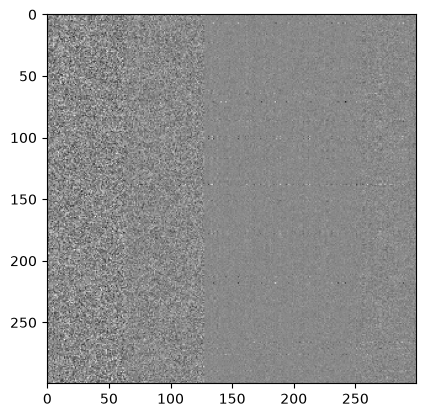

In [19]:
plt.imshow(sd_hf['transformer.h.1.attn.c_attn.weight'][:300,:300],cmap='grey')

In [51]:
from transformers import pipeline, set_seed

generator = pipeline('text-generation', model='gpt2')
set_seed(92)
generator("Wassup ",max_length=100, num_return_sequences=10)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 28439.87it/s]
[transformers] Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Wassup \xa0(K.P.D.R.A.K.)\nK.P.D.R.A.K. is a "Hacker House." According to the website, the house is a hacking factory run by K.P.D.R.A.K., which makes gadgets for people to hack. This is not the first time hackers have been involved in the hacking community. In November of 2012, K.P.D.R.A.K. uploaded a video of a person dressed in black and wearing headphones. The video included a scene from a recent cyber attack, in which a hacker is shown trying to hack into servers of a bank.\nAfter this attack, K.P.D.R.A.K. started to have a new name, which it called "K-P." The new name has since been changed to "P-P," but it remains a secret, because K.P.D.R.A.K. doesn\'t have any known users. One of them, E.C., is a hacker who just started hacking. He also claimed to be a "hacktivist" and claimed to work as a "hacktivist." E.C. has claimed to have hacked'},
 {'generated_text': "Wassup !!! !!!\n\nBassnection !!! !!!\n\nFeminist !!! !!!\n\nMacho !!! !!!\n\nTitan !!! !!!\n\nDude

In [4]:
# using the shakespear dataset : 

with open('input.txt','r') as f:
    text = f.read()
data = text[:100] #first 1k characters
print(data)


First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [ ]:
#importing gpt2 tokenizer
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:24])


[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


In [ ]:
import torch
buf=torch.tensor(tokens[:24+1]) # including the gt
x=buf[:-1].view(4,6) 
y=buf[1:].view(4,6)
print(x)
print(y)
# getting both context and gt for all possible positions

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])
